## Cell 1 — imports & config


In [1]:
import json
import os
import tarfile

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- where the data lives / where the artifact goes ---
BUCKET = "jonno-lucas-steve-bucket"
PREFIX = "usd-aai540-group1"
GOLD_S3 = f"s3://{BUCKET}/{PREFIX}/gold/model_training_matrix_foodsvc/"
MODEL_DIR = "model_artifacts"            # local scratch dir for the artifact

# --- modeling choices (the decisions we locked in) ---
TARGET = "food_svc_taxable_sales_usd"
DROP_COLS = [
    "food_svc_taxable_sales_usd",        # target
    "total_all_outlets_usd",             # LEAKAGE: target is a component of this
    "county_fips", "state_fips", "county_name", "period_id",  # identifiers
    "year",                              # temporal split key, not a feature
]
TRAIN_YEARS = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
VAL_YEARS = [2022]
TEST_YEARS = [2023]
LOG_TARGET = True                        # fit on log1p(y), report in dollars
SEED = 42

XGB_PARAMS = dict(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

In [5]:
%pip install --force-reinstall sagemaker

  Using cached sagemaker-3.13.1-py3-none-any.whl.metadata (20 kB)
  Using cached sagemaker_core-2.13.1-py3-none-any.whl.metadata (5.7 kB)


  Using cached sagemaker_train-1.13.1-py3-none-any.whl.metadata (8.2 kB)
  Using cached sagemaker_serve-1.13.1-py3-none-any.whl.metadata (14 kB)
  Using cached sagemaker_mlops-1.13.1-py3-none-any.whl.metadata (19 kB)


  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)


  Using cached prettytable-3.17.0-py3-none-any.whl.metadata (34 kB)


  Installing build dependencies ... -

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 171/174 [sagemaker-serve]

  Attempting uninstall: sagemaker-mlops
    Found existing installation: sagemaker-mlops 1.13.1
    Uninstalling sagemaker-mlops-1.13.1:
      Successfully uninstalled sagemaker-mlops-1.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 172/174 [sagemaker-mlops]

  Attempting uninstall: sagemaker
    Found existing installation: sagemaker 3.13.1
    Uninstalling sagemaker-3.13.1:
      Successfully uninstalled sagemaker-3.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 173/174 [sagemaker]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174/174 [sagemaker]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
dash 2.18.1 requires dash-core-components==2.0.0, which is not installed.
dash 2.18.1 requires dash-html-components==2.0.0, which is not installed.
dash 2.18.1 requires dash-table==5.0.0, which is not installed.
aiobotocore 3.7.0 requires botocore<1.43.1,>=1.42.90, but you have botocore 1.43.24 which is incompatible.
amazon-sagemaker-sql-editor 0.2.4 requires rpds-py==0.27.1, but you have rpds-py 2026.5.1 which is incom

Note: you may need to restart the kernel to use updated packages.


## Cell 2 — load the gold table from S3


In [2]:
# pip install -q awswrangler   # uncomment if the import fails
import awswrangler as wr

df = wr.s3.read_parquet(GOLD_S3, dataset=True)   # dataset=True restores the `year` partition
# alt via the catalog:
# df = wr.athena.read_sql_query(
#     "SELECT * FROM aai540_gold.model_training_matrix_foodsvc", database="aai540_gold")
df["year"] = df["year"].astype(int)
print("loaded", df.shape, "years:", sorted(df["year"].unique()))
df.head()

2026-06-08 06:38:13,879	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 400535552 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.86gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-06-08 06:38:15,066	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


loaded (2088, 25) years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


,county_fips,state_fips,county_name,latitude,longitude,land_area_sqmi,quarter,period_id,food_svc_taxable_sales_usd,total_all_outlets_usd,...,n_festivals,total_festival_attendance,total_wages_usd,avg_employment,establishment_count,population,median_household_income,median_age,bachelor_or_higher_pct,year
0,06007,06,Butte County,39.666554,-121.600701,1677.131033,1,2015Q1,73088458,725610670,...,0,0,718585172,76218,7770,209470,68574,36.3,31.720564,2015
1,06015,06,Del Norte County,41.744691,-123.957660,1229.681684,1,2015Q1,5599963,54343322,...,0,0,68561665,7714,782,27293,66780,40.8,20.974160,2015
2,06065,06,Riverside County,33.746631,-115.993940,7303.023823,1,2015Q1,881417946,7960482590,...,0,0,7223106190,644370,54234,2449909,89672,36.7,25.084018,2015
3,06069,06,San Benito County,36.605527,-121.074077,1390.473848,1,2015Q1,13714308,130332097,...,0,0,158197461,14869,1492,66056,108289,35.9,22.386651,2015
4,06085,06,Santa Clara County,37.232434,-121.695833,1304.055700,1,2015Q1,1042756339,9299382913,...,0,0,28350454751,993351,66161,1903297,159674,37.9,55.865627,2015


## Cell 3 — feature engineering & feature list

In [3]:
df["covid"] = df["year"].isin([2020, 2021]).astype(int)   # explicit anomaly flag

feature_cols = sorted(c for c in df.columns if c not in DROP_COLS)
print(len(feature_cols), "features:")
print(feature_cols)

19 features:
['avg_employment', 'bachelor_or_higher_pct', 'covid', 'establishment_count', 'land_area_sqmi', 'latitude', 'longitude', 'median_age', 'median_household_income', 'n_events', 'n_festivals', 'n_setlistfm', 'n_ticketmaster', 'population', 'quarter', 'total_est_attendance', 'total_expected_attendance', 'total_festival_attendance', 'total_wages_usd']


## Cell 4 — temporal split (never random)


In [4]:
def split_xy(years):
    d = df[df["year"].isin(years)]
    X = d[feature_cols].astype(float)
    y = d[TARGET].astype(float)
    return X, y, (np.log1p(y) if LOG_TARGET else y)

Xtr, ytr, ytr_fit = split_xy(TRAIN_YEARS)
Xva, yva, yva_fit = split_xy(VAL_YEARS)
Xte, yte, _ = split_xy(TEST_YEARS)
print(f"train={len(Xtr)}  val={len(Xva)}  test={len(Xte)}")
assert min(len(Xtr), len(Xva), len(Xte)) > 0, "a split is empty — check the year lists"

train=1624  val=232  test=232


## Cell 5 — train


In [5]:
model = xgb.XGBRegressor(**XGB_PARAMS)
model.fit(Xtr, ytr_fit, eval_set=[(Xva, yva_fit)], verbose=False)
print("best_iteration:", getattr(model, "best_iteration", None))

best_iteration: 399


## Cell 6 — evaluate on val & 2023 holdout


In [6]:
def predict_usd(X):
    p = model.predict(X)
    return np.expm1(p) if LOG_TARGET else p

def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = np.where(np.abs(y_true) < 1.0, np.nan, y_true)
    return {
        "rmse_usd": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae_usd": float(mean_absolute_error(y_true, y_pred)),
        "mape_pct": float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100),
        "r2": float(r2_score(y_true, y_pred)),
    }

m_val = metrics(yva.values, predict_usd(Xva))
m_test = metrics(yte.values, predict_usd(Xte))
print("VAL :", json.dumps(m_val, indent=2))
print("TEST:", json.dumps(m_test, indent=2))

VAL : {
  "rmse_usd": 149363034.43025157,
  "mae_usd": 55114426.972454205,
  "mape_pct": 13.162227971160052,
  "r2": 0.9790236484403326
}
TEST: {
  "rmse_usd": 198594001.52334744,
  "mae_usd": 72468249.29323815,
  "mape_pct": 15.37212590419273,
  "r2": 0.96645579589996
}


## Cell 7 — feature importance (the event-detectability check)


 0.3626  avg_employment
 0.3357  total_wages_usd
 0.1717  population
 0.0847  establishment_count
 0.0111  bachelor_or_higher_pct
 0.0101  land_area_sqmi
 0.0088  median_household_income
 0.0046  latitude
 0.0021  median_age
 0.0019  longitude
 0.0015  quarter
 0.0012  covid
 0.0011  total_festival_attendance
 0.0010  n_setlistfm
 0.0008  total_est_attendance
 0.0007  n_events
 0.0003  n_festivals
 0.0000  n_ticketmaster
 0.0000  total_expected_attendance


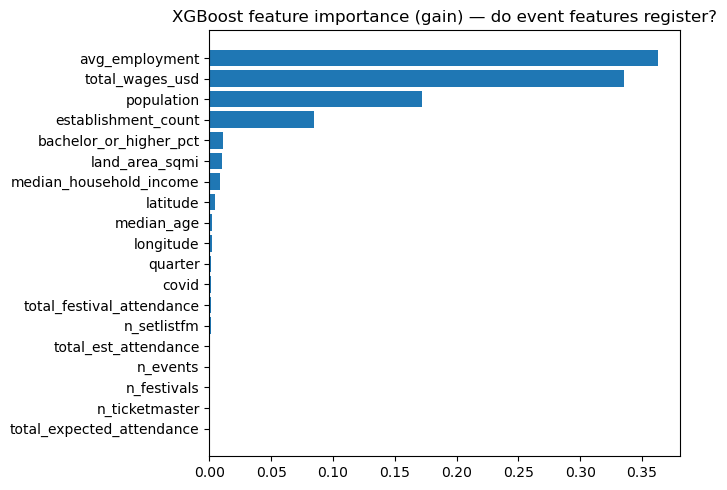

In [7]:
importances = sorted(
    zip(feature_cols, model.feature_importances_.tolist()),
    key=lambda t: t[1], reverse=True,
)
for name, val in importances:
    print(f"{val:7.4f}  {name}")

import matplotlib.pyplot as plt
names, vals = zip(*importances[::-1])
plt.figure(figsize=(7, 5))
plt.barh(names, vals)
plt.title("XGBoost feature importance (gain) — do event features register?")
plt.tight_layout()
plt.show()

## Cell 8 — save a registry-ready artifact & upload to S3


In [8]:
os.makedirs(MODEL_DIR, exist_ok=True)
model.get_booster().save_model(os.path.join(MODEL_DIR, "xgboost-model.json"))
with open(os.path.join(MODEL_DIR, "model_metadata.json"), "w") as f:
    json.dump(
        {
            "target": TARGET,
            "log_target": LOG_TARGET,
            "feature_cols": feature_cols,
            "best_iteration": getattr(model, "best_iteration", None),
            "train_years": TRAIN_YEARS, "val_years": VAL_YEARS, "test_years": TEST_YEARS,
            "metrics": {"val": m_val, "test": m_test},
        },
        f, indent=2,
    )

with tarfile.open("model.tar.gz", "w:gz") as tar:      # SageMaker expects files at tar root
    tar.add(os.path.join(MODEL_DIR, "xgboost-model.json"), arcname="xgboost-model.json")
    tar.add(os.path.join(MODEL_DIR, "model_metadata.json"), arcname="model_metadata.json")

import boto3
key = f"{PREFIX}/models/xgb-foodsvc/model.tar.gz"
boto3.client("s3").upload_file("model.tar.gz", BUCKET, key)
model_s3 = f"s3://{BUCKET}/{key}"
print("model artifact uploaded to:", model_s3)

model artifact uploaded to: s3://jonno-lucas-steve-bucket/usd-aai540-group1/models/xgb-foodsvc/model.tar.gz


In [9]:
import boto3
from botocore.exceptions import ClientError

MODEL_S3  = "s3://jonno-lucas-steve-bucket/usd-aai540-group1/models/xgb-foodsvc/model.tar.gz"
IMAGE_URI = "257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-xgboost:1.7-1"
MPG = "eia-foodsvc-xgb"

sm = boto3.client("sagemaker", region_name="us-east-2")

try:
    sm.create_model_package_group(
        ModelPackageGroupName=MPG,
        ModelPackageGroupDescription="EIA — Food Services & Drinking Places taxable-sales XGBoost (CA county-quarter)",
    )
    print("created group", MPG)
except ClientError as e:
    print("group note:", e.response["Error"]["Code"])

resp = sm.create_model_package(
    ModelPackageGroupName=MPG,
    ModelPackageDescription="XGBoost; Y=Food Services & Drinking Places taxable sales, CA county-quarter 2015-2023.",
    InferenceSpecification={
        "Containers": [{"Image": IMAGE_URI, "ModelDataUrl": MODEL_S3}],
        "SupportedContentTypes": ["text/csv"],
        "SupportedResponseMIMETypes": ["text/csv"],
        "SupportedRealtimeInferenceInstanceTypes": ["ml.m5.large", "ml.t2.medium"],
        "SupportedTransformInstanceTypes": ["ml.m5.large"],
    },
    ModelApprovalStatus="PendingManualApproval",
    CustomerMetadataProperties={
        "target": "food_svc_taxable_sales_usd",
        "test_r2": "0.9665",
        "test_mape_pct": "15.37",
        "known_limitation": "event features near 0 gain. sales-level model dominated by county scale",
    },
)
print("registered:", resp["ModelPackageArn"])

group note: ValidationException


registered: arn:aws:sagemaker:us-east-2:541974874359:model-package/eia-foodsvc-xgb/3


In [10]:
import boto3
sm = boto3.client("sagemaker", region_name="us-east-2")

for p in sm.list_model_packages(ModelPackageGroupName="eia-foodsvc-xgb")["ModelPackageSummaryList"]:
    print(p["ModelPackageVersion"], p["ModelApprovalStatus"], p["ModelPackageArn"])

3 PendingManualApproval arn:aws:sagemaker:us-east-2:541974874359:model-package/eia-foodsvc-xgb/3
2 PendingManualApproval arn:aws:sagemaker:us-east-2:541974874359:model-package/eia-foodsvc-xgb/2
1 Approved arn:aws:sagemaker:us-east-2:541974874359:model-package/eia-foodsvc-xgb/1


## Cell 9 — experiment harness (refactor of cells 5–7 into a reusable function)

In [11]:
def run_experiment(y_train_fit, y_val_true, y_test_true, label,
                   invert=None, train_idx=None, val_idx=None, test_idx=None):
    """Fit XGB on a transformed target, score in the ORIGINAL dollar space.

    y_train_fit : target the model fits on (already transformed if needed)
    y_*_true    : ground truth in raw USD for honest scoring
    invert      : fn mapping model output -> USD (e.g. expm1, or undo per-capita)
                  None => model output already in USD space
    """
    m = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(Xtr, y_train_fit, eval_set=[(Xva, _val_fit_for(label))], verbose=False)

    def to_usd(X, idx):
        p = m.predict(X)
        return invert(p, idx) if invert else p

    val_pred  = to_usd(Xva, val_idx)
    test_pred = to_usd(Xte, test_idx)
    mv = metrics(y_val_true,  val_pred)
    mt = metrics(y_test_true, test_pred)

    imp = sorted(zip(feature_cols, m.feature_importances_.tolist()),
                 key=lambda t: t[1], reverse=True)
    event_feats = ["n_events", "total_est_attendance", "total_expected_attendance",
                   "n_setlistfm", "n_ticketmaster", "n_festivals", "total_festival_attendance"]
    event_share = sum(v for n, v in imp if n in event_feats)

    print(f"\n=== {label} ===")
    print(f"VAL  r2={mv['r2']:.4f}  mape={mv['mape_pct']:.2f}%")
    print(f"TEST r2={mt['r2']:.4f}  mape={mt['mape_pct']:.2f}%")
    print(f"top3: {[f'{n}:{v:.3f}' for n,v in imp[:3]]}")
    print(f"event-feature gain share: {event_share:.4f}")
    return {"label": label, "val": mv, "test": mt,
            "importance": imp, "event_share": event_share, "model": m}

# small shim so the harness can grab the right val-fit target per experiment
_val_fit = {}
def _val_fit_for(label): return _val_fit[label]

## Cell 10 — Experiment A (raw target) re-run through the harness, as the baseline of record

In [12]:
_val_fit["A: raw USD (log1p)"] = yva_fit
expA = run_experiment(
    y_train_fit = ytr_fit,                 # log1p(raw) — same as your cell 5
    y_val_true  = yva.values,
    y_test_true = yte.values,
    label       = "A: raw USD (log1p)",
    invert      = lambda p, idx: np.expm1(p),
)


=== A: raw USD (log1p) ===
VAL  r2=0.9790  mape=13.16%
TEST r2=0.9665  mape=15.37%
top3: ['avg_employment:0.363', 'total_wages_usd:0.336', 'population:0.172']
event-feature gain share: 0.0039


## Cell 11 — Experiment B (per-capita target)

In [13]:
# Divide the obvious scale axis (population) out of the target, fit, then multiply it
# back in to score in real dollars. Expect events to STAY near zero — that's the point:
# it shows scale-domination isn't population-specific.

pop_tr = Xtr["population"].values
pop_va = Xva["population"].values
pop_te = Xte["population"].values

# per-capita target, then log1p for the same heavy-tail treatment
ytr_pc = np.log1p(ytr.values / pop_tr)
yva_pc = np.log1p(yva.values / pop_va)

_val_fit["B: per-capita (log1p)"] = yva_pc
expB = run_experiment(
    y_train_fit = ytr_pc,
    y_val_true  = yva.values,
    y_test_true = yte.values,
    label       = "B: per-capita (log1p)",
    invert      = lambda p, idx: np.expm1(p) * idx,   # undo log1p, then re-multiply population
    val_idx     = pop_va,
    test_idx    = pop_te,
)


=== B: per-capita (log1p) ===
VAL  r2=0.9760  mape=18.09%
TEST r2=0.9604  mape=21.27%
top3: ['bachelor_or_higher_pct:0.351', 'median_household_income:0.145', 'population:0.099']
event-feature gain share: 0.0393


## Cell 12 — Experiment C (within-county demeaned target)
We subtract the mean food sales of each county from 

In [14]:
# Subtract each county's own mean from its target. Every row becomes "this county-quarter
# relative to this county's normal." All between-county level (size, affluence, everything
# constant within a county) is gone — only within-county temporal deviation remains, which
# is the dimension events actually occupy. THIS is the real test of event detectability.

# county mean computed on TRAIN ONLY (no leakage from val/test into the centering)
county_mean = ytr.groupby(Xtr.index.map(df["county_fips"])).mean()
# fall back to global train mean for any county absent from train
global_mean = ytr.mean()

def cmean(idx_series):
    fips = df.loc[idx_series.index, "county_fips"]
    return fips.map(county_mean).fillna(global_mean).values

mu_tr = cmean(Xtr); mu_va = cmean(Xva); mu_te = cmean(Xte)

ytr_dm = ytr.values - mu_tr          # deviations, in raw USD (no log — demeaned data is signed)
yva_dm = yva.values - mu_va

_val_fit["C: within-county demeaned"] = yva_dm
expC = run_experiment(
    y_train_fit = ytr_dm,
    y_val_true  = yva.values,
    y_test_true = yte.values,
    label       = "C: within-county demeaned",
    invert      = lambda p, idx: p + idx,    # add the county mean back -> dollars
    val_idx     = mu_va,
    test_idx    = mu_te,
)


=== C: within-county demeaned ===
VAL  r2=0.9795  mape=28.74%
TEST r2=0.9656  mape=36.53%
top3: ['covid:0.162', 'population:0.116', 'total_est_attendance:0.113']
event-feature gain share: 0.3556


In [15]:
# R-squared in demeaned space —
from sklearn.metrics import r2_score
val_dev_pred  = expC["model"].predict(Xva)          # model output IS the deviation
test_dev_pred = expC["model"].predict(Xte)
print("demeaned-space VAL  r2:", r2_score(yva_dm, val_dev_pred))
print("demeaned-space TEST r2:", r2_score(yte.values - mu_te, test_dev_pred))

demeaned-space VAL  r2: 0.5992863337540775
demeaned-space TEST r2: 0.48668738814067514


## Cell 13 — model card for v1 (boto3), with A/B/C as embedded evidence

In [20]:
import json, boto3
from botocore.exceptions import ClientError

sm = boto3.client("sagemaker", region_name="us-east-2")

V1_ARN = "arn:aws:sagemaker:us-east-2:541974874359:model-package/eia-foodsvc-xgb/1"
MODEL_S3 = "s3://jonno-lucas-steve-bucket/usd-aai540-group1/models/xgb-foodsvc/model.tar.gz"
IMAGE_URI = "257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-xgboost:1.7-1"

content = {
    "model_overview": {
        "model_description": (
            "XGBoost regression predicting quarterly taxable sales for the Food Services & "
            "Drinking Places category (CDTFA business-type C08) at the California county level, "
            "on a 58-county quarterly panel, 2015-2023. It predicts sales LEVEL from county "
            "characteristics; it is a sales-level estimator, NOT an event-impact attribution model."
        ),
        "model_owner": "Lucas — USD AAI-540 Group 1",
        "model_creator": "USD AAI-540 Group 1",
        "problem_type": "Regression",
        "algorithm_type": "XGBoost (gradient-boosted trees)",
        "model_id": V1_ARN,
        "model_name": "eia-foodsvc-xgb",
        "model_version": 1,
        "model_artifact": [MODEL_S3],
        "inference_environment": {"container_image": [IMAGE_URI]},
    },
    "intended_uses": {
        "purpose_of_model": (
            "Estimate quarterly Food Services & Drinking Places taxable sales for a California "
            "county from its economic/demographic characteristics and aggregate event activity. "
            "Modeling deliverable for an Economic Impact Assessment system; this version is the "
            "predictive baseline and a study of whether event effects are identifiable."
        ),
        "intended_uses": (
            "County-quarter food-services sales LEVEL estimation for California within the "
            "2015-2023 regime, and as the baseline against which within-county event-effect "
            "identification is developed."
        ),
        "factors_affecting_model_efficiency": (
            "Driven almost entirely by county scale (employment, wages, population). Degrades "
            "outside the training regime and for very small counties. Does not isolate the "
            "marginal effect of any individual event."
        ),
        "risk_rating": "Medium",
        "explanations_for_risk_rating": (
            "Low deployment risk (internal research tool, public aggregate data, no PII, no "
            "individual-level decisions). Rated Medium because the high headline R-squared invites "
            "misreading as event-impact attribution, which this model does NOT provide; causal "
            "misuse is the primary risk and is addressed in caveats."
        ),
    },
    "training_details": {
        "training_observations": (
            "Target: food_svc_taxable_sales_usd (CDTFA C08), chosen over Total All Outlets because "
            "Total contains the target as a component (leakage) and is even more scale-dominated. "
            "Panel: 58 CA counties x quarter, 2015-2023. Temporal split (never random): train "
            "2015-2021, val 2022, test 2023. Target fit on log1p; COVID (2020-2021) carried as an "
            "explicit covariate, not filtered. Leakage controls: total_all_outlets_usd and all "
            "identifiers dropped from features. Trained interactively (XGBRegressor, not a SageMaker "
            "training job): max_depth=5, learning_rate=0.05, n_estimators=400, subsample=0.8, "
            "colsample_bytree=0.8, early_stopping_rounds=30; best_iteration=399. 19 features."
        ),
        "training_job_details": {
            "training_datasets": [
                "aai540_gold.model_training_matrix_foodsvc (gold features JOIN aai540_silver."
                "cdtfa_taxable_sales filtered to C08 Food Services & Drinking Places)"
            ]
        },
    },
    "evaluation_details": [
        {
            "name": "Holdout evaluation — registered model (Run A, raw USD target)",
            "evaluation_observation": (
                "Strong level fit but scale-dominated: event features carry 0.4% of gain; "
                "top features are avg_employment (0.36), total_wages_usd (0.34), population (0.17). "
                "Predicts how big a county's restaurant economy is, not how events move it."
            ),
            "datasets": ["2023 holdout (test); 2022 (val)"],
            "metric_groups": [{
                "name": "Run A — raw USD (levels)",
                "metric_data": [
                    {"name": "test_r2_levels", "type": "number", "value": 0.9665},
                    {"name": "test_mape_pct", "type": "number", "value": 15.37},
                    {"name": "val_r2_levels", "type": "number", "value": 0.9790},
                    {"name": "val_mape_pct", "type": "number", "value": 13.16},
                    {"name": "event_feature_gain_share", "type": "number", "value": 0.0039},
                ],
            }],
        },
        {
            "name": "Diagnostic — per-capita target (Run B)",
            "evaluation_observation": (
                "Dividing out population only swapped size proxies for affluence proxies "
                "(bachelor_or_higher_pct 0.35, median_household_income 0.14). Event share rose to "
                "3.9% but is redistribution, not signal; MAPE worsened. Confirms the confound is "
                "between-county level in general, not population specifically."
            ),
            "datasets": ["2023 holdout (test); 2022 (val)"],
            "metric_groups": [{
                "name": "Run B — per-capita (levels)",
                "metric_data": [
                    {"name": "test_r2_levels", "type": "number", "value": 0.9604},
                    {"name": "test_mape_pct", "type": "number", "value": 21.27},
                    {"name": "event_feature_gain_share", "type": "number", "value": 0.0393},
                ],
            }],
        },
        {
            "name": "Diagnostic — within-county demeaned target (Run C)",
            "evaluation_observation": (
                "Removing all between-county level (county means computed on train only, no "
                "leakage) leaves only within-county temporal deviation — the dimension events "
                "occupy. Event-feature gain share rose to 35.6%, total_est_attendance became a "
                "top-3 feature, and the model predicts ~49% of deviation variance on the holdout "
                "year. R-squared here is measured in DEVIATION space (the hard part), not level "
                "space, so it is not comparable to the 0.97 levels figures above. Event lift is "
                "identifiable, but only within-county — not cross-sectionally."
            ),
            "datasets": ["2023 holdout (test); 2022 (val)"],
            "metric_groups": [{
                "name": "Run C — within-county demeaned (deviations)",
                "metric_data": [
                    {"name": "test_r2_deviation", "type": "number", "value": 0.4867},
                    {"name": "val_r2_deviation", "type": "number", "value": 0.5993},
                    {"name": "test_mape_pct", "type": "number", "value": 36.53},
                    {"name": "event_feature_gain_share", "type": "number", "value": 0.3556},
                ],
            }],
        },
    ],
    "additional_information": {
        "ethical_considerations": (
            "Aggregate public economic data; no personal data. Primary risk is economic-policy "
            "misattribution: presenting predicted sales levels as event-CAUSED impact could "
            "misinform subsidy or funding decisions. Use only as a predictive baseline; causal "
            "claims require the within-county identification strategy below."
        ),
        "caveats_and_recommendations": (
            "Headline limitation arc (A->B->C): cross-sectional models cannot see event lift "
            "because they fit between-county level — first by size (A, event share 0.4%), then by "
            "affluence (B, 3.9%); removing one scale axis only promotes the next. Only within-county "
            "demeaning (C) isolates the temporal dimension events occupy, raising event-feature "
            "share to 35.6% and reaching test R-squared 0.49 on the deviation itself. "
            "IMPORTANT: C shows events are CORRELATED with within-county sales movement, not that "
            "they CAUSED it — time-varying confounders (seasonality, local booms) are not removed by "
            "demeaning. Recommendations: (1) do not use this model for per-event dollar attribution; "
            "(2) capstone identification via difference-in-differences / synthetic control; "
            "(3) move to city-level CDTFA on high-signal Tier-3 cells (Indio, Napa, Paso Robles) "
            "where the event-to-base ratio is far higher than at county grain."
        ),
        "custom_details": {
            "model_package_arn": V1_ARN,
            "approval_status_at_card_creation": "PendingManualApproval",
            "target_category": "CDTFA C08 Food Services and Drinking Places",
            "geography_grain": "California county-quarter, 58 counties",
            "time_span": "2015-2023; temporal split train 2015-2021 / val 2022 / test 2023",
        },
    },
}

try:
    resp = sm.create_model_card(
        ModelCardName="eia-foodsvc-xgb-v1-card",
        Content=json.dumps(content),
        ModelCardStatus="Draft",
    )
    print("created card:", resp["ModelCardArn"])
except ClientError as e:
    print("card note:", e.response["Error"]["Code"], "-", e.response["Error"].get("Message", ""))

created card: arn:aws:sagemaker:us-east-2:541974874359:model-card/eia-foodsvc-xgb-v1-card


In [16]:
sm.update_model_package(
    ModelPackageArn="arn:aws:sagemaker:us-east-2:541974874359:model-package/eia-foodsvc-xgb/1",
    ModelApprovalStatus="Approved",
)
print("v1 approved for deployment")

v1 approved for deployment


## Cell 14 — add an inference handler and repackage model.tar.gz

In [24]:
inference_py = '''
import json, os
import numpy as np
import xgboost as xgb

FEATURE_ORDER = [
    "avg_employment","bachelor_or_higher_pct","covid","establishment_count",
    "land_area_sqmi","latitude","longitude","median_age","median_household_income",
    "n_events","n_festivals","n_setlistfm","n_ticketmaster","population","quarter",
    "total_est_attendance","total_expected_attendance","total_festival_attendance",
    "total_wages_usd",
]

def model_fn(model_dir):
    booster = xgb.Booster()
    booster.load_model(os.path.join(model_dir, "xgboost-model.json"))
    return booster

def input_fn(body, content_type):
    if content_type == "application/json":
        obj = json.loads(body)
        rows = obj["instances"] if isinstance(obj, dict) else obj
        if isinstance(rows[0], dict):                 # list of feature dicts
            rows = [[r[k] for k in FEATURE_ORDER] for r in rows]
        return np.asarray(rows, dtype=float)
    if content_type == "text/csv":                    # rows of comma-separated values
        return np.asarray(
            [list(map(float, line.split(","))) for line in body.strip().splitlines()],
            dtype=float,
        )
    raise ValueError("unsupported content type: " + str(content_type))

def predict_fn(arr, booster):
    log_pred = booster.predict(xgb.DMatrix(arr, feature_names=FEATURE_ORDER))
    return np.expm1(log_pred)                          # undo log1p -> dollars

def output_fn(pred, accept):
    return json.dumps({"predictions": pred.tolist()}), "application/json"
'''

import os, tarfile, boto3

os.makedirs("model_artifacts/code", exist_ok=True)
with open("model_artifacts/code/inference.py", "w") as f:
    f.write(inference_py)

# repackage: booster + metadata at root, inference.py under code/
with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model_artifacts/xgboost-model.json", arcname="xgboost-model.json")
    tar.add("model_artifacts/model_metadata.json", arcname="model_metadata.json")
    tar.add("model_artifacts/code/inference.py", arcname="code/inference.py")

key = "usd-aai540-group1/models/xgb-foodsvc/model.tar.gz"
boto3.client("s3").upload_file("model.tar.gz", "jonno-lucas-steve-bucket", key)
print("repackaged artifact uploaded:", f"s3://jonno-lucas-steve-bucket/{key}")

repackaged artifact uploaded: s3://jonno-lucas-steve-bucket/usd-aai540-group1/models/xgb-foodsvc/model.tar.gz


###### Cell 14b — booster-only artifact (no metadata file, no code/ dir)

In [35]:
import tarfile, boto3

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model_artifacts/xgboost-model.json", arcname="xgboost-model.json")

print("tar contents:", tarfile.open("model.tar.gz").getnames())   # should be exactly ['xgboost-model.json']

key = "usd-aai540-group1/models/xgb-foodsvc/model.tar.gz"
boto3.client("s3").upload_file("model.tar.gz", "jonno-lucas-steve-bucket", key)
print("uploaded booster-only artifact")

tar contents: ['xgboost-model.json']


uploaded booster-only artifact


## Cell 15 — approve v1, then deploy a real-time endpoint via boto3

In [37]:

import time, boto3
sm = boto3.client("sagemaker", region_name="us-east-2")

NAME      = "eia-foodsvc-xgb-v2"
ROLE_ARN  = "arn:aws:iam::541974874359:role/service-role/AmazonSageMaker-ExecutionRole-20260516T162536"
IMAGE_URI = "257758044811.dkr.ecr.us-east-2.amazonaws.com/sagemaker-xgboost:1.7-1"
MODEL_S3  = "s3://jonno-lucas-steve-bucket/usd-aai540-group1/models/xgb-foodsvc/model.tar.gz"

sm.create_model(
    ModelName=NAME,
    ExecutionRoleArn=ROLE_ARN,
    PrimaryContainer={"Image": IMAGE_URI, "ModelDataUrl": MODEL_S3},   # NO Environment block
)
sm.create_endpoint_config(
    EndpointConfigName=NAME,
    ProductionVariants=[{"VariantName": "AllTraffic", "ModelName": NAME,
                         "InstanceType": "ml.m5.large", "InitialInstanceCount": 1}],
)
sm.create_endpoint(EndpointName=NAME, EndpointConfigName=NAME)
print("deploying", NAME, "; polling...")
while True:
    s = sm.describe_endpoint(EndpointName=NAME)["EndpointStatus"]
    print(s)
    if s in ("InService", "Failed"):
        if s == "Failed":
            print("reason:", sm.describe_endpoint(EndpointName=NAME).get("FailureReason"))
        break
    time.sleep(30)

deploying eia-foodsvc-xgb-v2 ; polling...
Creating


Creating


Creating


Creating


Creating


Creating


Creating


InService


## Cell 16 — push to github
